In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/🏥ICU_Mortality_Prediction.csv",engine='python',on_bad_lines='skip')

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,hospital_death,age,bmi,gender,gcs_motor_apache,gcs_eyes_apache,gcs_verbal_apache,apache_2_diagnosis,apache_3j_bodysystem,d1_heartrate_max,d1_heartrate_min,d1_sysbp_min,d1_mbp_min,d1_spo2_min,d1_resprate_max,d1_temp_min,d1_temp_max,d1_lactate_min,d1_lactate_max,d1_bun_max,d1_creatinine_max,d1_albumin_min,d1_platelets_min,d1_wbc_max,d1_glucose_max,d1_sodium_min,ph_apache,d1_arterial_ph_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus,arf_apache,ventilated_apache,elective_surgery,icu_admit_source,apache_post_operative,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,d1_lactate_min_tested,d1_lactate_max_tested,ph_apache_tested,d1_arterial_ph_min_tested
0,0,68.0,22.73,M,6.0,3.0,4.0,113.0,Sepsis,119.0,72.0,73.0,46.0,74.0,34.0,37.2,39.9,1.0,1.3,31.0,2.51,2.3,233.0,14.1,168.0,134.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,Floor,0,0.10,0.05,1,1,0,0
1,0,77.0,27.42,F,3.0,1.0,1.0,108.0,Respiratory,118.0,72.0,67.0,38.0,70.0,32.0,35.1,36.3,3.5,3.5,11.0,0.71,1.6,487.0,23.3,145.0,145.0,7.45,7.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,Floor,0,0.47,0.29,1,1,1,1
2,0,25.0,31.95,F,6.0,3.0,5.0,122.0,Metabolic,96.0,68.0,105.0,68.0,91.0,21.0,36.7,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Accident & Emergency,0,0.00,0.00,0,0,0,0
3,0,81.0,22.64,F,6.0,4.0,5.0,203.0,Cardiovascular,116.0,92.0,84.0,84.0,95.0,23.0,34.8,38.0,NaN,NaN,NaN,NaN,NaN,43.0,9.0,185.0,NaN,7.39,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,Operating Room / Recovery,1,0.04,0.03,0,0,1,1
4,0,19.0,NaN,M,NaN,NaN,NaN,119.0,Trauma,89.0,60.0,120.0,90.0,96.0,18.0,36.7,37.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Accident & Emergency,0,NaN,NaN,0,0,0,0


In [5]:
df.shape

(91713, 47)

In [6]:
df.isnull().sum()

,0
hospital_death,0
age,4228
bmi,3429
gender,25
gcs_motor_apache,1901
gcs_eyes_apache,1901
gcs_verbal_apache,1901
apache_2_diagnosis,1662
apache_3j_bodysystem,1662
d1_heartrate_max,145


In [7]:
null_percentage = (df.isnull().sum() / len(df)) * 100

null_df = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null Percentage": null_percentage.round(2)
})

print(null_df.sort_values("Null Percentage", ascending=False))

                               Null Count  Null Percentage
ph_apache                           70868            77.27
d1_lactate_max                      68396            74.58
d1_lactate_min                      68396            74.58
d1_arterial_ph_min                  60123            65.56
d1_albumin_min                      49096            53.53
d1_platelets_min                    13444            14.66
d1_wbc_max                          13174            14.36
d1_bun_max                          10514            11.46
d1_sodium_min                       10195            11.12
d1_creatinine_max                   10169            11.09
apache_4a_icu_death_prob             7947             8.67
apache_4a_hospital_death_prob        7947             8.67
d1_glucose_max                       5807             6.33
age                                  4228             4.61
bmi                                  3429             3.74
d1_temp_max                          2324             2.

In [8]:
df.dtypes

,0
hospital_death,int64
age,float64
bmi,float64
gender,object
gcs_motor_apache,float64
gcs_eyes_apache,float64
gcs_verbal_apache,float64
apache_2_diagnosis,float64
apache_3j_bodysystem,object
d1_heartrate_max,float64


In [9]:
# Step 1: capture "was this tested" BEFORE filling — do this first
for col in ['d1_lactate_min', 'd1_lactate_max', 'ph_apache', 'd1_arterial_ph_min', 'd1_albumin_min']:
    df[col + '_tested'] = df[col].notna().astype(int)

# Step 2: now fill as you were doing
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    elif df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())

print("Missing values filled successfully, with tested-flags preserved!")

Missing values filled successfully, with tested-flags preserved!


In [10]:
df.isnull().sum()

,0
hospital_death,0
age,0
bmi,0
gender,0
gcs_motor_apache,0
gcs_eyes_apache,0
gcs_verbal_apache,0
apache_2_diagnosis,0
apache_3j_bodysystem,0
d1_heartrate_max,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
y = df['hospital_death']
X = df.drop(columns=['hospital_death'])


In [13]:
df.head()

,hospital_death,age,bmi,gender,gcs_motor_apache,gcs_eyes_apache,gcs_verbal_apache,apache_2_diagnosis,apache_3j_bodysystem,d1_heartrate_max,d1_heartrate_min,d1_sysbp_min,d1_mbp_min,d1_spo2_min,d1_resprate_max,d1_temp_min,d1_temp_max,d1_lactate_min,d1_lactate_max,d1_bun_max,d1_creatinine_max,d1_albumin_min,d1_platelets_min,d1_wbc_max,d1_glucose_max,d1_sodium_min,ph_apache,d1_arterial_ph_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus,arf_apache,ventilated_apache,elective_surgery,icu_admit_source,apache_post_operative,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,d1_lactate_min_tested,d1_lactate_max_tested,ph_apache_tested,d1_arterial_ph_min_tested,d1_albumin_min_tested
0,0,68.0,22.730000,M,6.0,3.0,4.0,113.0,Sepsis,119.0,72.0,73.0,46.0,74.0,34.0,37.2,39.9,1.0,1.3,31.0,2.51,2.3,233.0,14.1,168.0,134.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,Floor,0,0.10,0.05,1,1,0,0,1
1,0,77.0,27.420000,F,3.0,1.0,1.0,108.0,Respiratory,118.0,72.0,67.0,38.0,70.0,32.0,35.1,36.3,3.5,3.5,11.0,0.71,1.6,487.0,23.3,145.0,145.0,7.45,7.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,Floor,0,0.47,0.29,1,1,1,1,1
2,0,25.0,31.950000,F,6.0,3.0,5.0,122.0,Metabolic,96.0,68.0,105.0,68.0,91.0,21.0,36.7,37.0,1.5,1.9,19.0,1.00,2.9,187.0,11.0,150.0,138.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Accident & Emergency,0,0.00,0.00,0,0,0,0,0
3,0,81.0,22.640000,F,6.0,4.0,5.0,203.0,Cardiovascular,116.0,92.0,84.0,84.0,95.0,23.0,34.8,38.0,1.5,1.9,19.0,1.00,2.9,43.0,9.0,185.0,138.0,7.39,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,Operating Room / Recovery,1,0.04,0.03,0,0,1,1,0
4,0,19.0,27.654655,M,6.0,4.0,5.0,119.0,Trauma,89.0,60.0,120.0,90.0,96.0,18.0,36.7,37.2,1.5,1.9,19.0,1.00,2.9,187.0,11.0,150.0,138.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Accident & Emergency,0,0.05,0.02,0,0,0,0,0


In [14]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for binary column
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])   # F=0, M=1 (or vice versa)

# One-Hot Encoding for multi-category columns
df = pd.get_dummies(
    df,
    columns=["apache_3j_bodysystem", "icu_admit_source"],
    drop_first=True
)

In [15]:
df.head()

,hospital_death,age,bmi,gender,gcs_motor_apache,gcs_eyes_apache,gcs_verbal_apache,apache_2_diagnosis,d1_heartrate_max,d1_heartrate_min,d1_sysbp_min,d1_mbp_min,d1_spo2_min,d1_resprate_max,d1_temp_min,d1_temp_max,d1_lactate_min,d1_lactate_max,d1_bun_max,d1_creatinine_max,d1_albumin_min,d1_platelets_min,d1_wbc_max,d1_glucose_max,d1_sodium_min,ph_apache,d1_arterial_ph_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus,arf_apache,ventilated_apache,elective_surgery,apache_post_operative,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,d1_lactate_min_tested,d1_lactate_max_tested,ph_apache_tested,d1_arterial_ph_min_tested,d1_albumin_min_tested,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU
0,0,68.0,22.730000,1,6.0,3.0,4.0,113.0,119.0,72.0,73.0,46.0,74.0,34.0,37.2,39.9,1.0,1.3,31.0,2.51,2.3,233.0,14.1,168.0,134.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0.10,0.05,1,1,0,0,1,False,False,False,False,False,False,False,False,True,False,True,False,False,False
1,0,77.0,27.420000,0,3.0,1.0,1.0,108.0,118.0,72.0,67.0,38.0,70.0,32.0,35.1,36.3,3.5,3.5,11.0,0.71,1.6,487.0,23.3,145.0,145.0,7.45,7.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0.47,0.29,1,1,1,1,1,False,False,False,False,False,False,False,True,False,False,True,False,False,False
2,0,25.0,31.950000,0,6.0,3.0,5.0,122.0,96.0,68.0,105.0,68.0,91.0,21.0,36.7,37.0,1.5,1.9,19.0,1.00,2.9,187.0,11.0,150.0,138.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.00,0.00,0,0,0,0,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,0,81.0,22.640000,0,6.0,4.0,5.0,203.0,116.0,92.0,84.0,84.0,95.0,23.0,34.8,38.0,1.5,1.9,19.0,1.00,2.9,43.0,9.0,185.0,138.0,7.39,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,0.04,0.03,0,0,1,1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,0,19.0,27.654655,1,6.0,4.0,5.0,119.0,89.0,60.0,120.0,90.0,96.0,18.0,36.7,37.2,1.5,1.9,19.0,1.00,2.9,187.0,11.0,150.0,138.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.05,0.02,0,0,0,0,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [16]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [17]:
df.head()

,hospital_death,age,bmi,gender,gcs_motor_apache,gcs_eyes_apache,gcs_verbal_apache,apache_2_diagnosis,d1_heartrate_max,d1_heartrate_min,d1_sysbp_min,d1_mbp_min,d1_spo2_min,d1_resprate_max,d1_temp_min,d1_temp_max,d1_lactate_min,d1_lactate_max,d1_bun_max,d1_creatinine_max,d1_albumin_min,d1_platelets_min,d1_wbc_max,d1_glucose_max,d1_sodium_min,ph_apache,d1_arterial_ph_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus,arf_apache,ventilated_apache,elective_surgery,apache_post_operative,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,d1_lactate_min_tested,d1_lactate_max_tested,ph_apache_tested,d1_arterial_ph_min_tested,d1_albumin_min_tested,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU
0,0,68.0,22.730000,1,6.0,3.0,4.0,113.0,119.0,72.0,73.0,46.0,74.0,34.0,37.2,39.9,1.0,1.3,31.0,2.51,2.3,233.0,14.1,168.0,134.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0.10,0.05,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0
1,0,77.0,27.420000,0,3.0,1.0,1.0,108.0,118.0,72.0,67.0,38.0,70.0,32.0,35.1,36.3,3.5,3.5,11.0,0.71,1.6,487.0,23.3,145.0,145.0,7.45,7.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0.47,0.29,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
2,0,25.0,31.950000,0,6.0,3.0,5.0,122.0,96.0,68.0,105.0,68.0,91.0,21.0,36.7,37.0,1.5,1.9,19.0,1.00,2.9,187.0,11.0,150.0,138.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.00,0.00,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,81.0,22.640000,0,6.0,4.0,5.0,203.0,116.0,92.0,84.0,84.0,95.0,23.0,34.8,38.0,1.5,1.9,19.0,1.00,2.9,43.0,9.0,185.0,138.0,7.39,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,0.04,0.03,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0,19.0,27.654655,1,6.0,4.0,5.0,119.0,89.0,60.0,120.0,90.0,96.0,18.0,36.7,37.2,1.5,1.9,19.0,1.00,2.9,187.0,11.0,150.0,138.0,7.36,7.34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.05,0.02,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [18]:
import pandas as pd
import numpy as np

# Load dataset
# df = pd.read_csv("your_dataset.csv")

total_outliers = 0

print("Outliers in Numeric Columns:\n")

# Only numeric columns (int + float)
numeric_cols = df.select_dtypes(include=['int64', 'float64','object']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers}")
    total_outliers += outliers

# Total values in numeric columns
total_numeric_values = len(df) * len(numeric_cols)

# Percentage
outlier_percentage = (total_outliers / total_numeric_values) * 100

print("\n" + "="*40)
print(f"Integer Columns : {len(df.select_dtypes(include='int64').columns)}")
print(f"Float Columns   : {len(df.select_dtypes(include='float64').columns)}")
print(f"Object Columns  : {len(df.select_dtypes(include='object').columns)}")
print("="*40)
print(f"Total Outliers  : {total_outliers}")
print(f"Outlier Percentage : {outlier_percentage:.2f}%")

Outliers in Numeric Columns:

hospital_death: 7915
age: 772
bmi: 3665
gender: 0
gcs_motor_apache: 18852
gcs_eyes_apache: 8274
gcs_verbal_apache: 18681
apache_2_diagnosis: 0
d1_heartrate_max: 1460
d1_heartrate_min: 1984
d1_sysbp_min: 1795
d1_mbp_min: 1795
d1_spo2_min: 5973
d1_resprate_max: 4638
d1_temp_min: 7320
d1_temp_max: 5572
d1_lactate_min: 22382
d1_lactate_max: 22651
d1_bun_max: 7566
d1_creatinine_max: 10656
d1_albumin_min: 40219
d1_platelets_min: 4440
d1_wbc_max: 5532
d1_glucose_max: 6406
d1_sodium_min: 6181
ph_apache: 20088
d1_arterial_ph_min: 30584
aids: 78
cirrhosis: 1428
hepatic_failure: 1182
immunosuppression: 2381
leukemia: 643
lymphoma: 376
solid_tumor_with_metastasis: 1878
diabetes_mellitus: 20492
arf_apache: 2546
ventilated_apache: 0
elective_surgery: 16851
apache_post_operative: 18444
apache_4a_hospital_death_prob: 12174
apache_4a_icu_death_prob: 13377
d1_lactate_min_tested: 0
d1_lactate_max_tested: 0
ph_apache_tested: 20845
d1_arterial_ph_min_tested: 0
d1_albumin_min_t

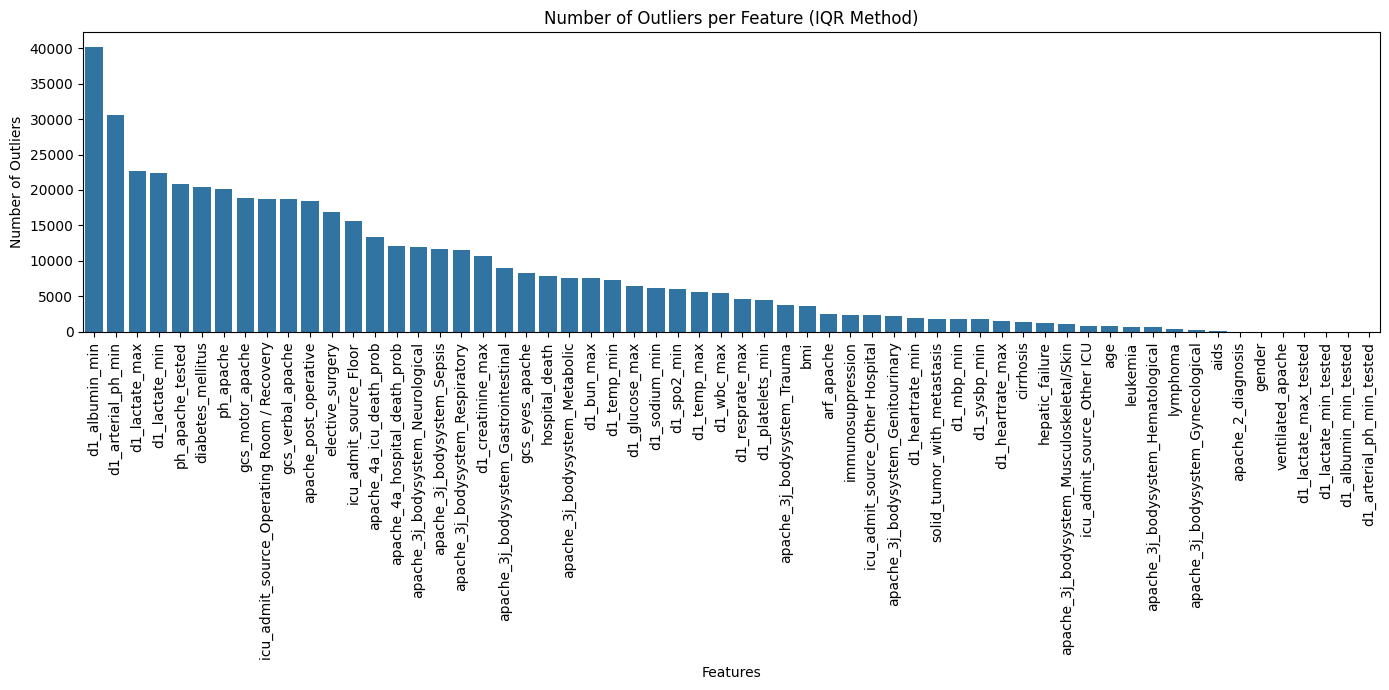

In [19]:




import matplotlib.pyplot as plt
import seaborn as sns

outlier_data = {}
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_data[col] = count

outlier_df = pd.DataFrame(list(outlier_data.items()), columns=['Feature', 'Outlier_Count'])

plt.figure(figsize=(14, 7))
sns.barplot(x='Feature', y='Outlier_Count', data=outlier_df.sort_values(by='Outlier_Count', ascending=False))
plt.xticks(rotation=90)
plt.title('Number of Outliers per Feature (IQR Method)')
plt.xlabel('Features')
plt.ylabel('Number of Outliers')
plt.tight_layout()
plt.show()

In [20]:
df['hospital_death'].value_counts()

,count
hospital_death,
0,83798
1,7915


In [21]:

df['hospital_death'].value_counts(normalize=True)*100

,proportion
hospital_death,
0,91.369817
1,8.630183


In [22]:
corr_matrix = df.corr(numeric_only=True)

high_corr = (
    corr_matrix.where(abs(corr_matrix) > 0.8)
    .stack()
    .reset_index()
)
print(corr_matrix)

                                            hospital_death       age  \
hospital_death                                    1.000000  0.108306   
age                                               0.108306  1.000000   
bmi                                              -0.031006 -0.086472   
gender                                           -0.006811 -0.026549   
gcs_motor_apache                                 -0.273661  0.025728   
gcs_eyes_apache                                  -0.250703  0.026379   
gcs_verbal_apache                                -0.231056 -0.017073   
apache_2_diagnosis                               -0.088434  0.020766   
d1_heartrate_max                                  0.162708 -0.132919   
d1_heartrate_min                                 -0.003605 -0.140982   
d1_sysbp_min                                     -0.209809 -0.058955   
d1_mbp_min                                       -0.194937 -0.129646   
d1_spo2_min                                      -0.209326 -0.08

In [23]:
df.corr(numeric_only=True)["hospital_death"].sort_values(ascending=False)

,hospital_death
hospital_death,1.000000
d1_lactate_max,0.309711
d1_lactate_min,0.309619
apache_4a_hospital_death_prob,0.300259
apache_4a_icu_death_prob,0.274050
ventilated_apache,0.226405
d1_arterial_ph_min_tested,0.196743
d1_lactate_max_tested,0.179123
d1_lactate_min_tested,0.179123
ph_apache_tested,0.177250


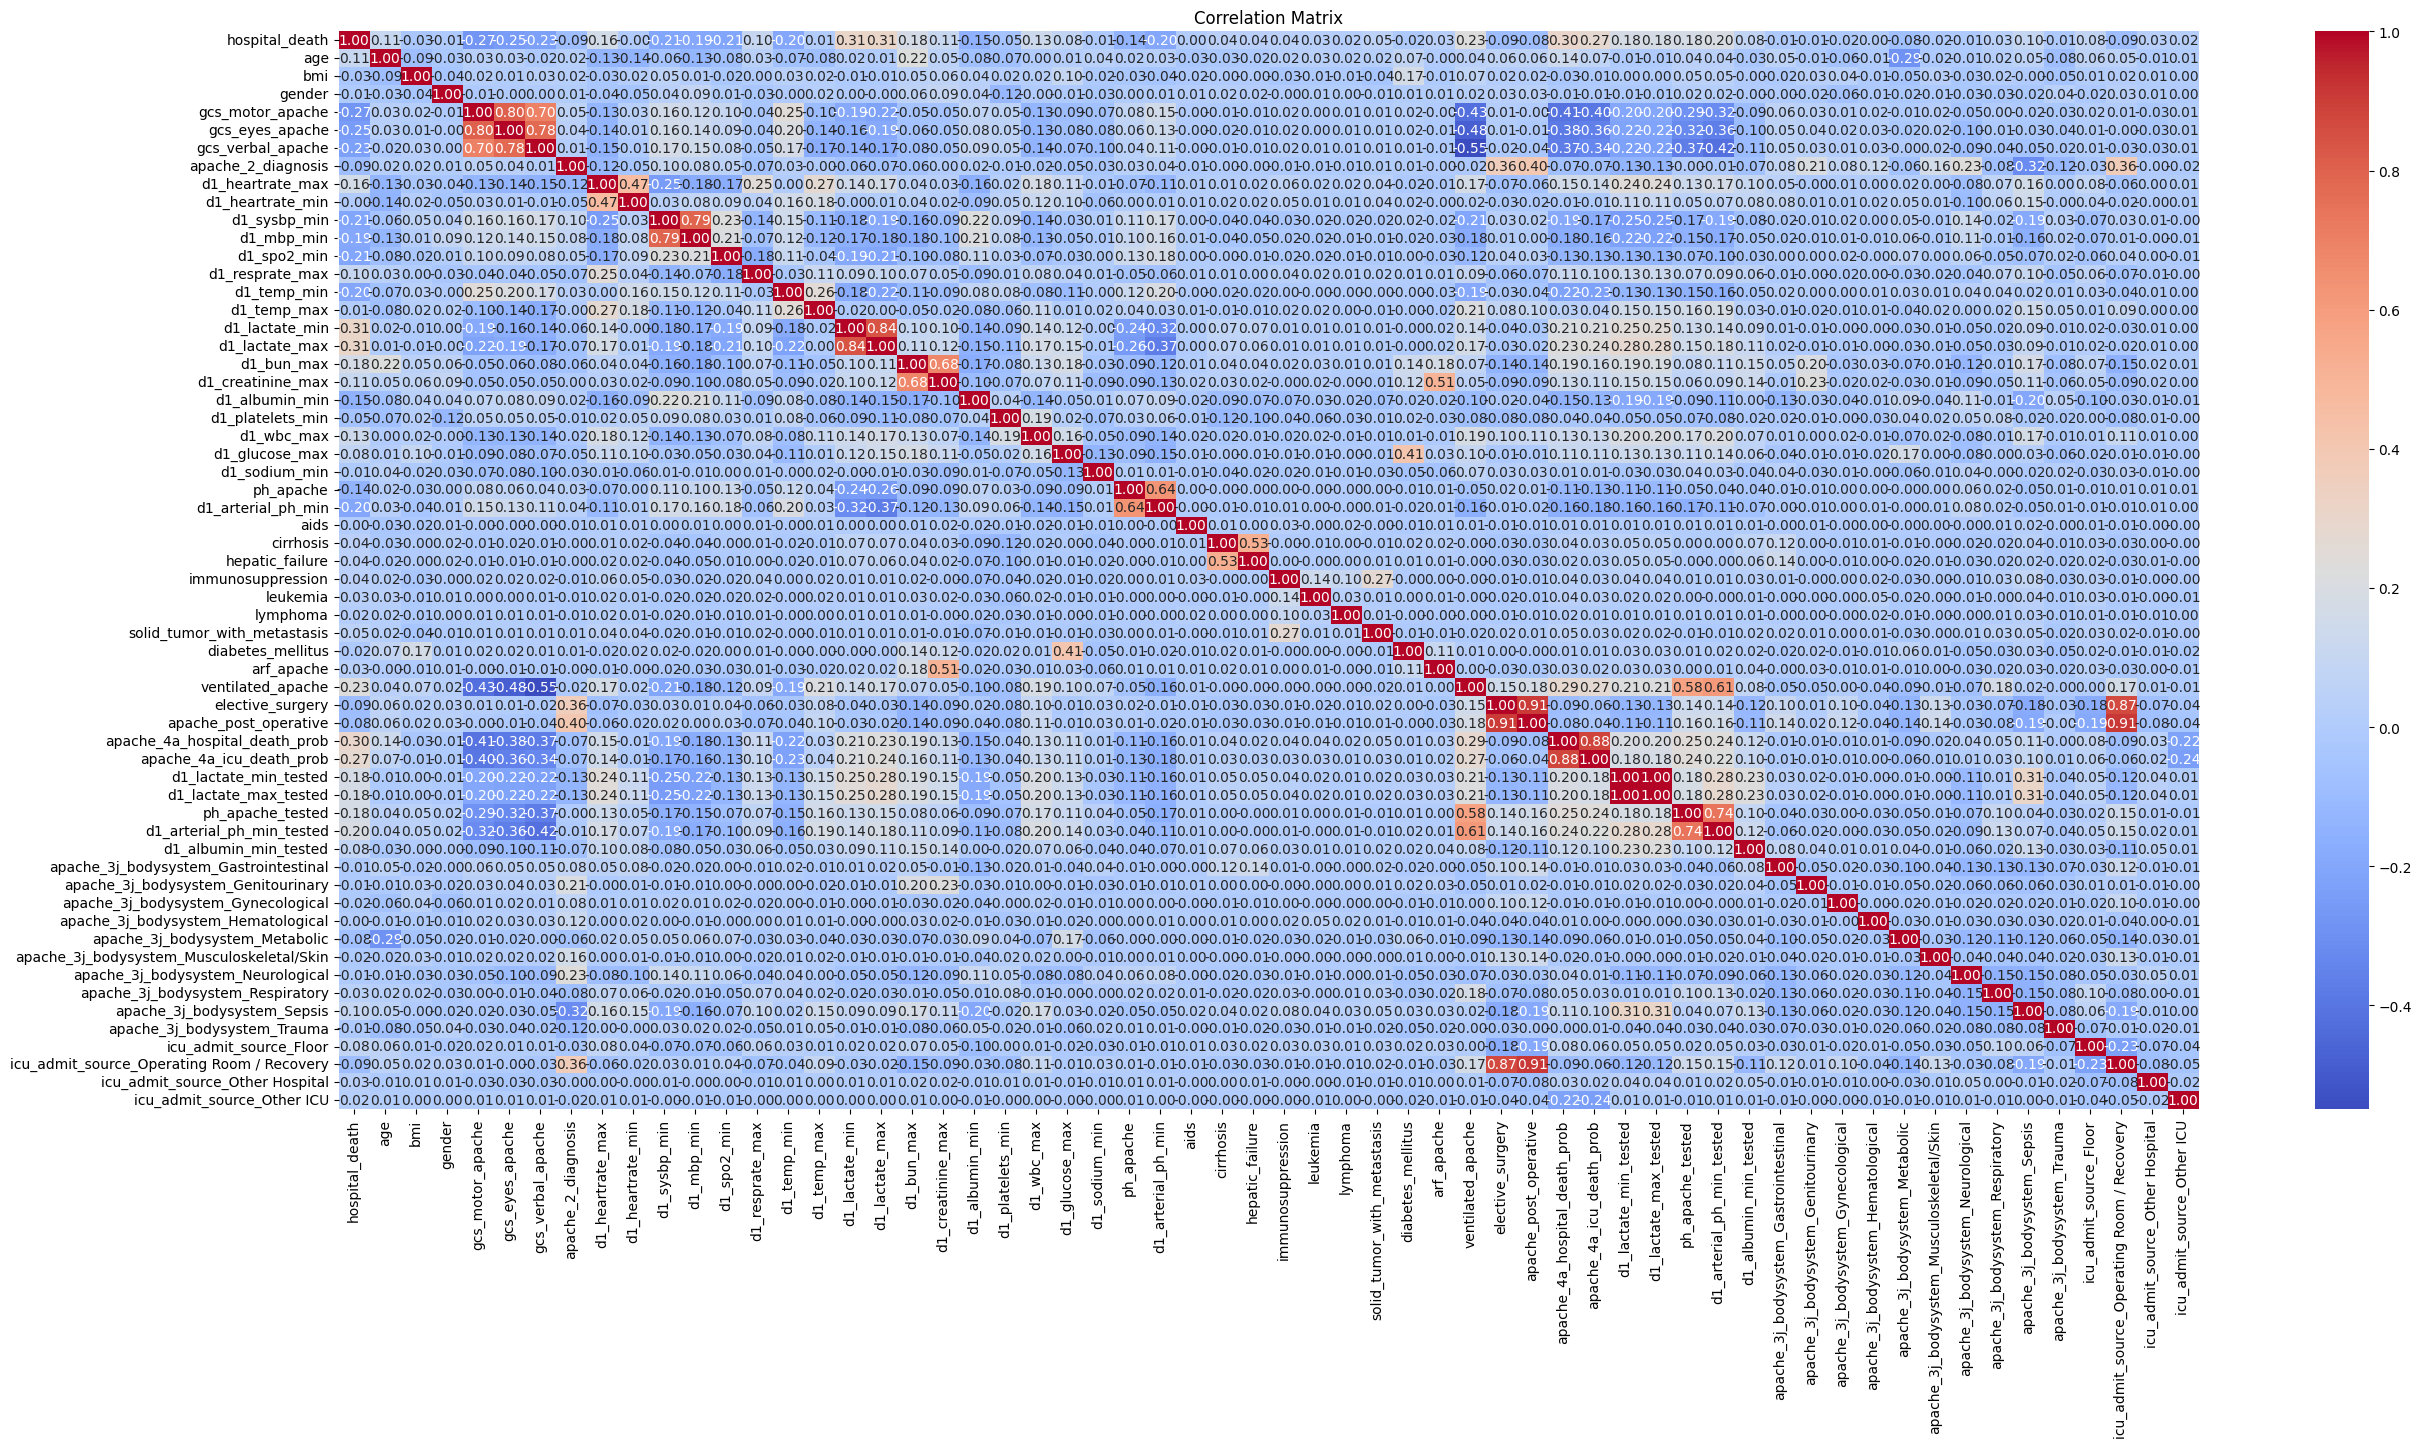

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(30,14))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

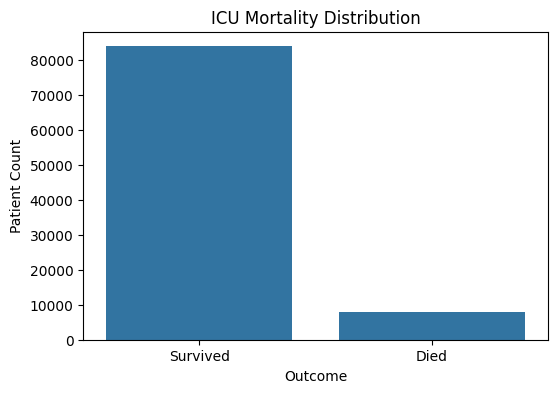

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='hospital_death', data=df)
plt.xticks([0,1], ['Survived', 'Died'])
plt.title("ICU Mortality Distribution")
plt.xlabel("Outcome")
plt.ylabel("Patient Count")
plt.show()

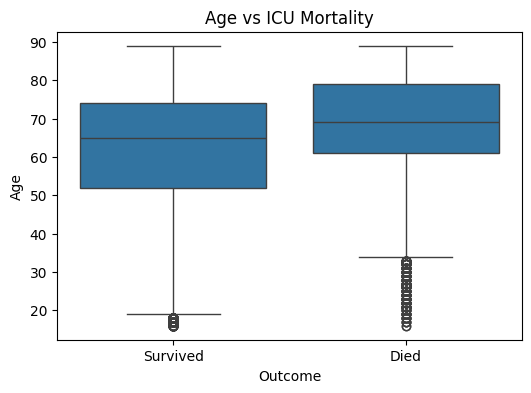

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x='hospital_death', y='age', data=df)
plt.xticks([0,1], ['Survived', 'Died'])
plt.title("Age vs ICU Mortality")
plt.xlabel("Outcome")
plt.ylabel("Age")
plt.show()

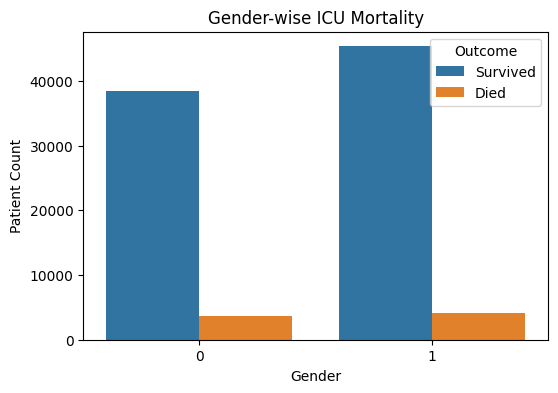

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='hospital_death', data=df)
plt.title("Gender-wise ICU Mortality")
plt.xlabel("Gender")
plt.ylabel("Patient Count")
plt.legend(title="Outcome", labels=["Survived", "Died"])
plt.show()

In [28]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop("hospital_death", axis=1)   # Replace with your target column
y = df["hospital_death"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (73370, 59)
X_test : (18343, 59)
y_train: (73370,)
y_test : (18343,)


In [29]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [30]:
print(y_train.value_counts())

hospital_death
1    67038
0    67038
Name: count, dtype: int64


In [31]:
print("Original Dataset:", df.shape)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print(y.value_counts())

Original Dataset: (91713, 60)
X_train: (134076, 59)
X_test : (18343, 59)
hospital_death
0    83798
1     7915
Name: count, dtype: int64


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
baseline_model = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for potential convergence with scaled data
baseline_model.fit(X_train_scaled, y_train)

# Predicted probabilities
y_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Set threshold
threshold = 0.3

# Apply threshold
y_pred = (y_prob >= threshold).astype(int)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7482418361227716
Precision: 0.21122740247383445
Recall   : 0.7012002526847757
F1 Score : 0.324656332260895
ROC AUC  : 0.8082466676818282


In [65]:
baseline_model.score(X_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.08629995093496157

In [66]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance":baseline_model.coef_[0]
})

# Sort
importance = importance.sort_values(by="Importance", ascending=False)

# Get the feature names from the importance DataFrame
feature_cols = importance["Feature"].tolist()

# Filter the feature_cols to only include those present in the current 'df'
# This handles cases where some columns might have been dropped from 'df'
# after X_train was created.
ordered_columns = [col for col in feature_cols if col in df.columns]

# Add the target column 'hospital_death' to the end if it's not already there
# and if it exists in the original dataframe 'df'
if 'hospital_death' in df.columns and 'hospital_death' not in ordered_columns:
    ordered_columns.append("hospital_death")

# Rearrange dataframe
df = df[ordered_columns]

print(df.head())

   d1_lactate_min  ventilated_apache   age  d1_bun_max  \
0             1.0                0.0  68.0        31.0   
1             3.5                1.0  77.0        11.0   
2             1.5                0.0  25.0        19.0   
3             1.5                1.0  81.0        19.0   
4             1.5                0.0  19.0        19.0   

   apache_4a_hospital_death_prob  apache_post_operative  d1_heartrate_max  \
0                           0.10                      0             119.0   
1                           0.47                      0             118.0   
2                           0.00                      0              96.0   
3                           0.04                      1             116.0   
4                           0.05                      0              89.0   

   d1_wbc_max  solid_tumor_with_metastasis  d1_heartrate_min  d1_temp_max  \
0        14.1                          0.0              72.0         39.9   
1        23.3                     

In [67]:
import pandas as pd
pd.set_option('display.max_rows', None)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance":baseline_model.coef_[0]
})

# Sort
importance = importance.sort_values(by="Importance", ascending=False)

# Show all features
print(importance)
pd.reset_option('display.max_rows')

                                       Feature  Importance
10                              d1_lactate_min    0.755812
27                           ventilated_apache    0.652349
0                                          age    0.478139
12                                  d1_bun_max    0.477477
30               apache_4a_hospital_death_prob    0.450364
29                       apache_post_operative    0.426780
5                             d1_heartrate_max    0.337900
15                                  d1_wbc_max    0.181248
24                 solid_tumor_with_metastasis    0.178889
6                             d1_heartrate_min    0.164827
9                                  d1_temp_max    0.156656
19                                   cirrhosis    0.137393
11                              d1_lactate_max    0.134240
7                              d1_resprate_max    0.108795
20                             hepatic_failure    0.097596
26                                  arf_apache    0.0974

In [69]:
df.shape

(91713, 51)

In [72]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

model = random_search.best_estimator_

# ---------- Threshold ----------
threshold = 0.35

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nBest Parameters:")
print(random_search.best_params_)

Accuracy : 0.8972905195442403
Precision: 0.43048498845265587
Recall   : 0.5887555274794694
F1 Score : 0.4973319103521878
ROC AUC  : 0.8844033488271115

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}


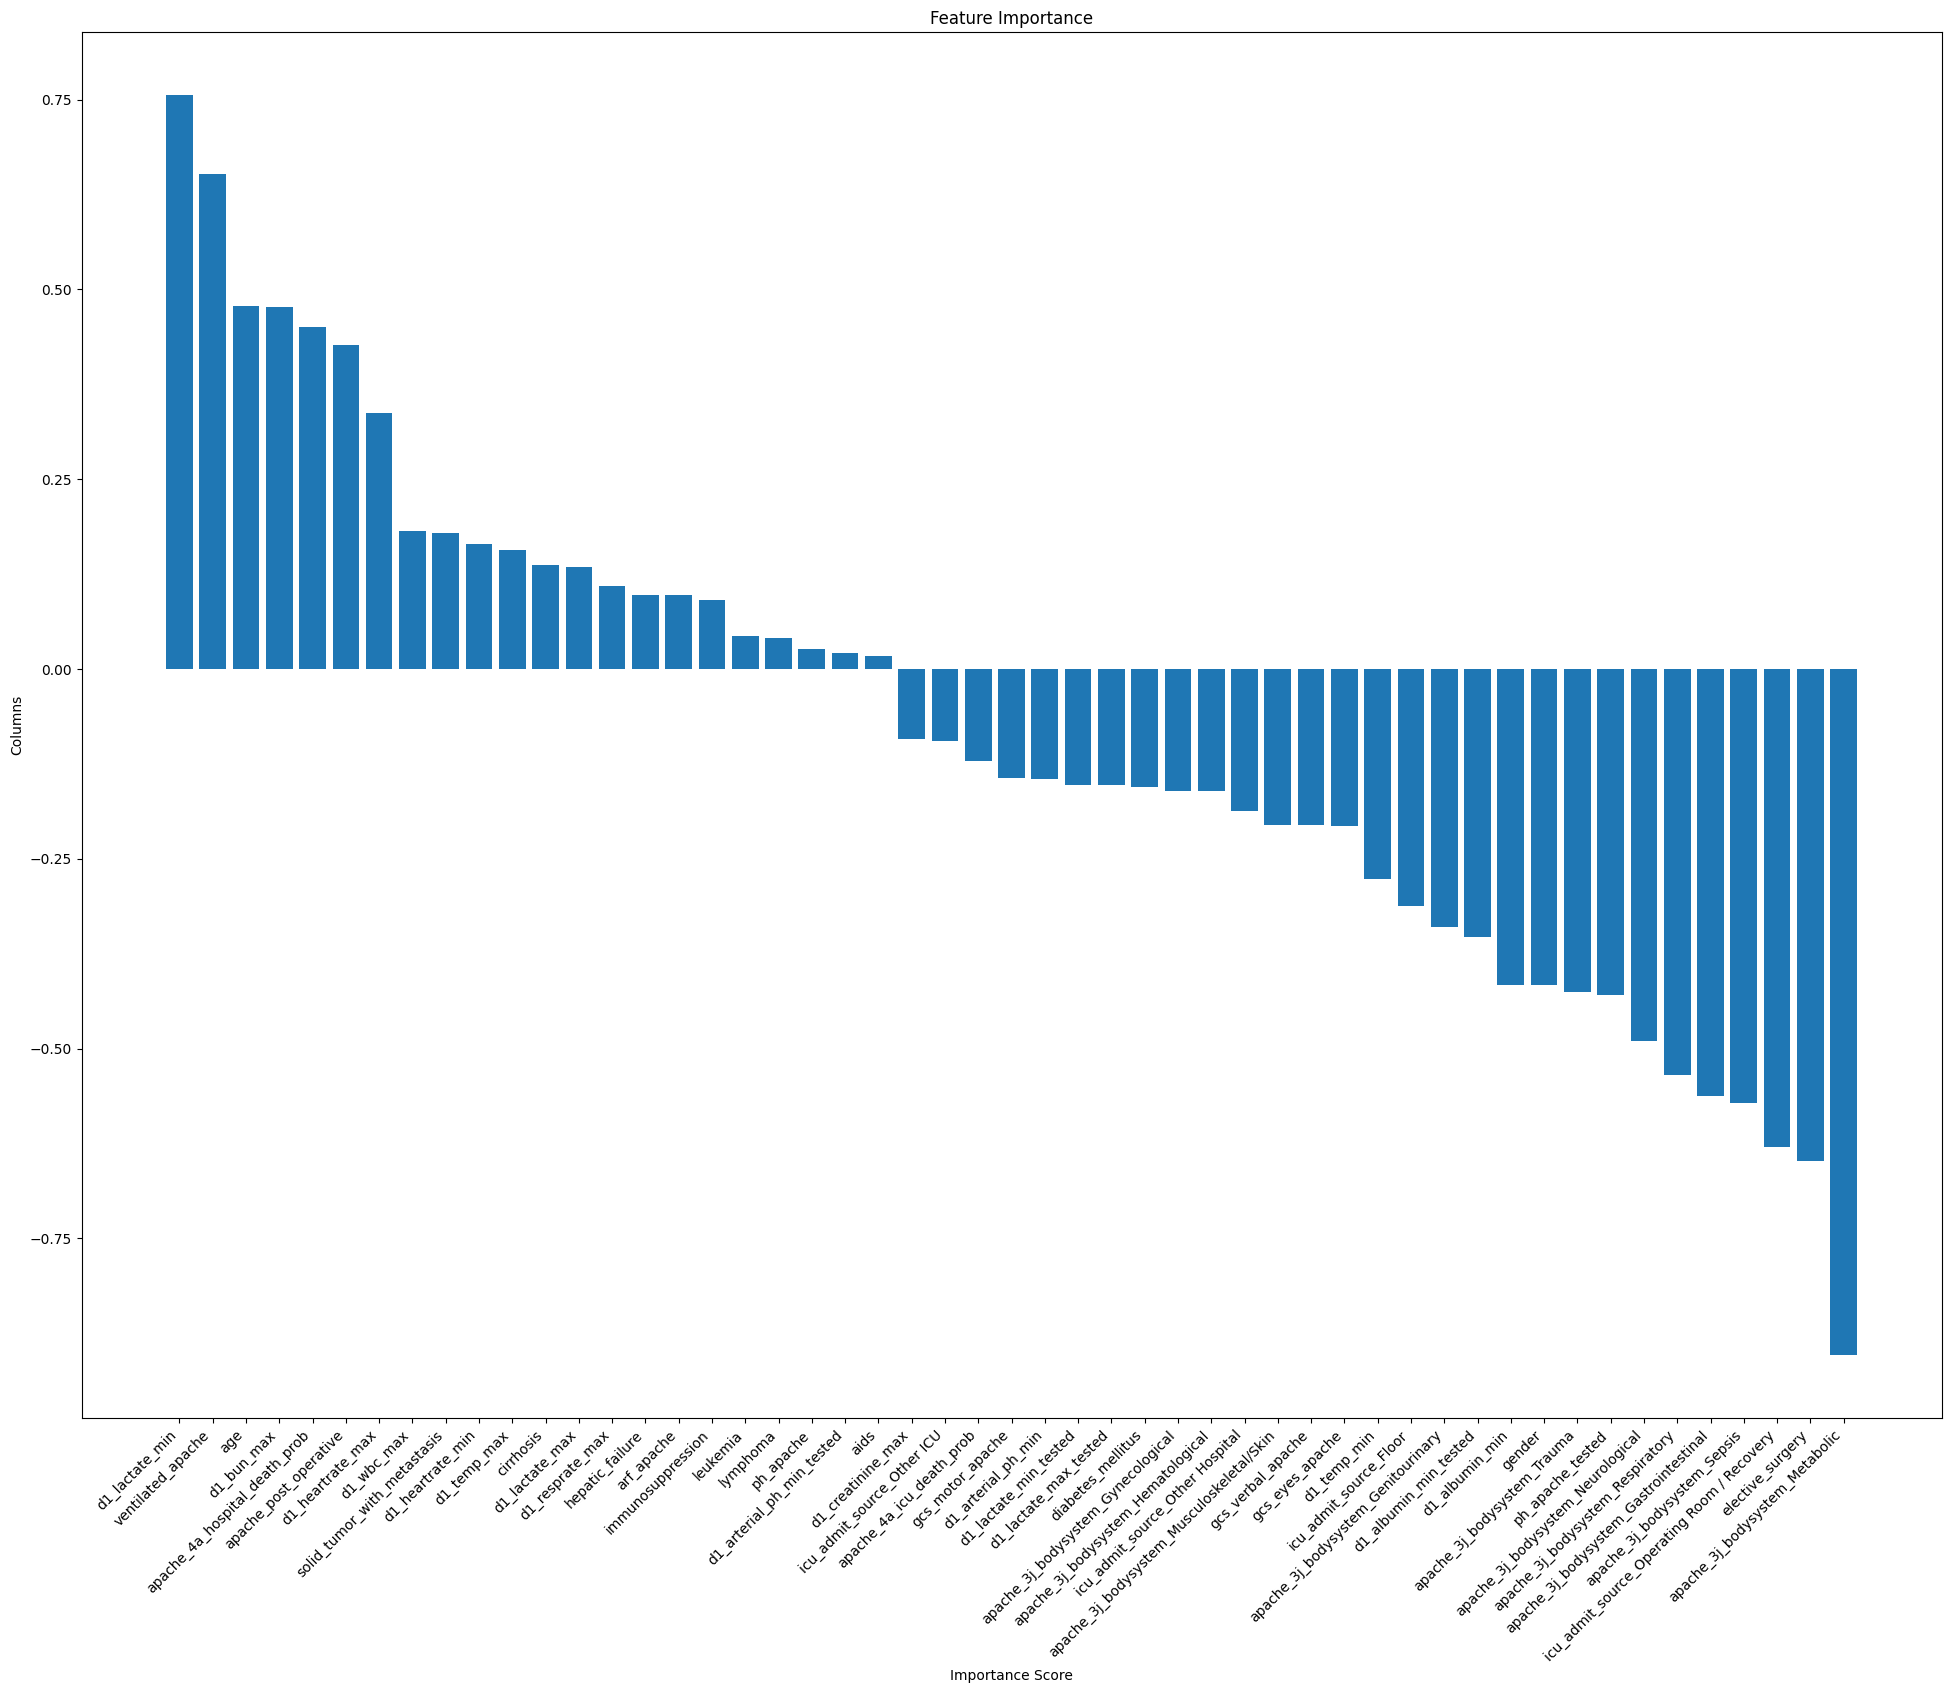

In [73]:
plt.figure(figsize=(24,18))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.xlabel("Importance Score")
plt.ylabel("Columns")
plt.title("Feature Importance")
plt.xticks(rotation=45, ha='right')
plt.show()

In [74]:
import pickle
pickle.dump(xgb, open("🏥ICU_Mortality_Prediction.pkl", "wb"))